# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is "linear" if it is linear in its parameters (coefficients), not necessarily in the input variables. This means the model is a weighted sum of the coefficients. Even if we include transformations like x^2 or log(x), the model is still linear as long as the coefficients enter the model linearly.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient on a dummy variable represents the difference in the outcome compared to a baseline category (the one that is left out). The intercept corresponds to the baseline group, and the dummy coefficient shows how much higher or lower the predicted value is relative to that baseline, holding other variables constant.

3. Can linear regression be used for classification? Explain why, or why not.

Yes, but it is not ideal. Linear regression can produce predictions outside the range of 0 to 1, which does not make sense for probabilities. It also does not model classification boundaries well. That is why logistic regression is usually preferred.

4. What are signs that your linear model is over-fitting?

- Very high accuracy on training data but low accuracy on test data
- Large changes in predictions when using different samples
- Very large or unstable coefficients
- Adding more features improves training performance but not test performance

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity occurs when independent variables are highly correlated, making it difficult to separate their individual effects. In a two-stage approach, you first predict one of the correlated variables using other variables. Then you use that predicted value in the regression instead of the original variable. This removes the shared variation and helps isolate the true effect.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can add transformed or new features such as:

- Polynomial terms like x^2 or x^3
- Log transformations like log(x)
- Interaction terms like x1 * x2

This allows the model to capture nonlinear relationships while still being linear in coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient represents the expected change in y for a one-unit increase in x, holding all other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

- Train/test split: Simple and fast, but results depend on how the data is split
- k-fold cross validation: Splits the data into k groups and rotates which group is used for testing, giving a more reliable estimate but taking more time

9. How is the $k$ in $k$-fold cross validation typically selected?

k is usually chosen based on a balance between accuracy and computation time. Common choices are 5 or 10. Smaller k is faster but less stable, while larger k is more accurate but more computationally expensive.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.



In [5]:
from google.colab import files
uploaded = files.upload()

Saving Q1_clean.csv to Q1_clean (1).csv


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# load data
df = pd.read_csv("Q1_clean.csv")

# clean column names (fixes ALL issues)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# check columns
print(df.columns)

# create log price
df["log_price"] = np.log(df["price"])


Index(['price', 'review_scores_rating', 'neighbourhood', 'property_type',
       'room_type'],
      dtype='object')


1. Average prices + KDE plots


Group Means:
                     price  review_scores_rating
neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750

Most expensive borough: Manhattan


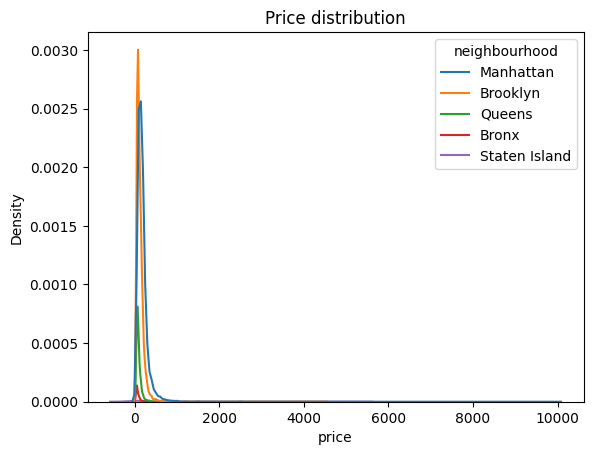

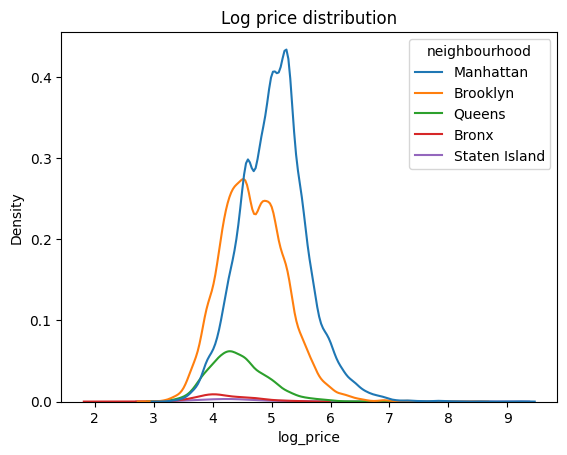

In [13]:
group_means = df.groupby("neighbourhood")[["price", "review_scores_rating"]].mean()
print("\nGroup Means:\n", group_means)

most_expensive = group_means["price"].idxmax()
print("\nMost expensive borough:", most_expensive)

# KDE plots
sns.kdeplot(data=df, x="price", hue="neighbourhood")
plt.title("Price distribution")
plt.show()

sns.kdeplot(data=df, x="log_price", hue="neighbourhood")
plt.title("Log price distribution")
plt.show()

2. Regression: Price on Neighbourhood

In [20]:
dummies = pd.get_dummies(df["neighbourhood"], drop_first=True).astype(float)

X1 = sm.add_constant(dummies)
y = df["price"].astype(float)

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        07:10:47   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

3. Regression: Price on Review Score

In [16]:
X2 = sm.add_constant(df["review_scores_rating"])

model2 = sm.OLS(y, X2).fit()
print("\nModel 2 Summary:\n", model2.summary())


Model 2 Summary:
                             OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        07:09:27   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const        

4. Regression: Price on Neighbourhood + Review Score

In [21]:
X3 = pd.concat([dummies, df[["review_scores_rating"]]], axis=1)
X3 = sm.add_constant(X3).astype(float)
model3 = sm.OLS(y, X3).fit()

print("\n================ MODEL 3: Price ~ Neighbourhood + Review Scores Rating ================\n")
print(model3.summary())



================ MODEL 3: Price ~ Neighbourhood + Review Scores Rating ================

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        07:13:42   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

5. Different slopes by neighbourhood (interaction)

In [22]:
interaction_terms = dummies.multiply(df["review_scores_rating"], axis=0)
interaction_terms.columns = [col + "_x_review" for col in interaction_terms.columns]

X4 = pd.concat([dummies, df[["review_scores_rating"]], interaction_terms], axis=1)
X4 = sm.add_constant(X4).astype(float)
model4 = sm.OLS(y, X4).fit()

print("\n================ MODEL 4: Interaction Model ================\n")
print(model4.summary())



================ MODEL 4: Interaction Model ================

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:13:51   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

6. Cross-validation

In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
lr = LinearRegression()

# sklearn inputs
X_cv2 = df[["review_scores_rating"]].astype(float)
X_cv3 = pd.concat([dummies, df[["review_scores_rating"]]], axis=1).astype(float)
X_cv4 = pd.concat([dummies, df[["review_scores_rating"]], interaction_terms], axis=1).astype(float)

mse2 = -cross_val_score(lr, X_cv2, y, cv=kf, scoring="neg_mean_squared_error").mean()
mse3 = -cross_val_score(lr, X_cv3, y, cv=kf, scoring="neg_mean_squared_error").mean()
mse4 = -cross_val_score(lr, X_cv4, y, cv=kf, scoring="neg_mean_squared_error").mean()

r2_2 = cross_val_score(lr, X_cv2, y, cv=kf, scoring="r2").mean()
r2_3 = cross_val_score(lr, X_cv3, y, cv=kf, scoring="r2").mean()
r2_4 = cross_val_score(lr, X_cv4, y, cv=kf, scoring="r2").mean()

print("\n================ CROSS VALIDATION RESULTS ================\n")
print("Model 2: Price ~ Review Scores Rating")
print("CV Mean MSE:", mse2)
print("CV Mean R^2:", r2_2)

print("\nModel 3: Price ~ Neighbourhood + Review Scores Rating")
print("CV Mean MSE:", mse3)
print("CV Mean R^2:", r2_3)

print("\nModel 4: Price ~ Neighbourhood + Review Scores Rating + Interactions")
print("CV Mean MSE:", mse4)
print("CV Mean R^2:", r2_4)


================ CROSS VALIDATION RESULTS ================

Model 2: Price ~ Review Scores Rating
CV Mean MSE: 22078.215444464753
CV Mean R^2: 0.0037072341987201217

Model 3: Price ~ Neighbourhood + Review Scores Rating
CV Mean MSE: 21068.500019790663
CV Mean R^2: 0.056425362821514294

Model 4: Price ~ Neighbourhood + Review Scores Rating + Interactions
CV Mean MSE: 21293.768998593318
CV Mean R^2: 0.046269053122810176


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [24]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw.csv to cars_hw.csv


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# -------------------------
# Load and clean data
# -------------------------
df = pd.read_csv("cars_hw.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

df = df[["price", "seating_capacity", "body_type", "make_year"]].dropna().copy()

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["seating_capacity"] = pd.to_numeric(df["seating_capacity"], errors="coerce")
df["make_year"] = pd.to_numeric(df["make_year"], errors="coerce")
df = df.dropna().copy()

print("Columns:", df.columns.tolist())
print(df.head())



Columns: ['price', 'seating_capacity', 'body_type', 'make_year']
    price  seating_capacity  body_type  make_year
0  657000                 5      sedan       2017
1  682000                 5  crossover       2016
2  793000                 5        suv       2019
3  414000                 5  hatchback       2017
4  515000                 5  hatchback       2017



Price Summary:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: price, dtype: float64

Price by Body Type:
           count          mean            std       min       25%        50%  \
body_type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
body_type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  294100

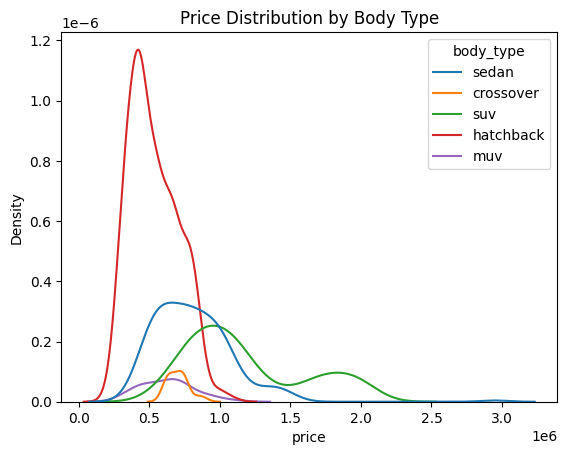

In [27]:
# -------------------------
# 1. Summary + KDE
# -------------------------
print("\nPrice Summary:")
print(df["price"].describe())

group_stats = df.groupby("body_type")["price"].describe()
print("\nPrice by Body Type:")
print(group_stats)

most_expensive = df.groupby("body_type")["price"].mean().idxmax()
highest_variance = df.groupby("body_type")["price"].var().idxmax()

print("\nMost expensive body type:", most_expensive)
print("Highest variance body type:", highest_variance)

sns.kdeplot(data=df, x="price", hue="body_type")
plt.title("Price Distribution by Body Type")
plt.show()

In [29]:
# -------------------------
# 2. Regression: Price ~ Seating Capacity
# -------------------------
X = sm.add_constant(df[["seating_capacity"]]).astype(float)
y = df["price"].astype(float)

model = sm.OLS(y, X).fit()
print("\nModel: Price ~ Seating Capacity")
print(model.summary())

seat_dummies = pd.get_dummies(df["seating_capacity"], drop_first=True).astype(float)
X_dum = sm.add_constant(seat_dummies)

model_dum = sm.OLS(y, X_dum).fit()
print("\nModel: Price ~ Seating Capacity (Categorical)")
print(model_dum.summary())



Model: Price ~ Seating Capacity
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0245
Time:                        07:22:34   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const  

In [30]:
# -------------------------
# 3. Create Age + CV for polynomial
# -------------------------
current_year = df["make_year"].max()
df["age"] = current_year - df["make_year"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = [1, 2, 3, 4, 5]
mse_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(df[["age"]])

    lr = LinearRegression()
    mse = -cross_val_score(lr, X_poly, df["price"], cv=kf,
                           scoring="neg_mean_squared_error").mean()

    mse_scores.append(mse)

print("\nPolynomial CV Results:")
for d, mse in zip(degrees, mse_scores):
    print(f"Degree {d}: {mse}")

best_degree = degrees[np.argmin(mse_scores)]
print("\nBest degree:", best_degree)



Polynomial CV Results:
Degree 1: 97745760011.44075
Degree 2: 97815319552.31636
Degree 3: 97304076284.38516
Degree 4: 96785385468.56345
Degree 5: 95816293470.49446

Best degree: 5


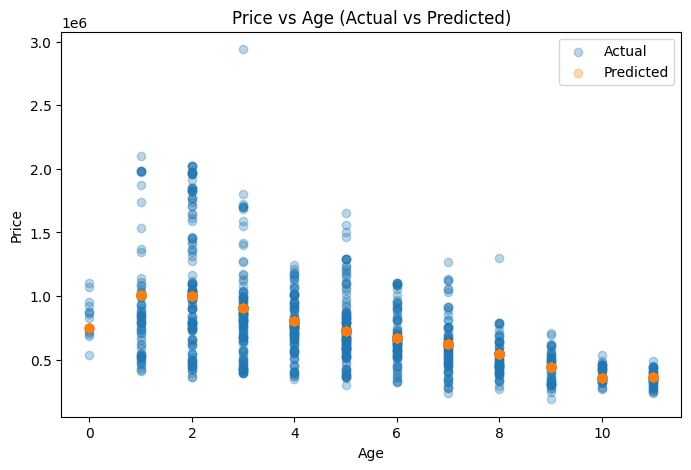

In [31]:
# -------------------------
# 4. Plot actual vs predicted
# -------------------------
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(df[["age"]])

lr = LinearRegression()
lr.fit(X_poly, df["price"])

df["predicted_price"] = lr.predict(X_poly)

plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["price"], alpha=0.3, label="Actual")
plt.scatter(df["age"], df["predicted_price"], alpha=0.3, label="Predicted")
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age (Actual vs Predicted)")
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [25]:
from google.colab import files
uploaded = files.upload()

Saving heart_hw.csv to heart_hw.csv


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# -------------------------
# Load and clean data
# -------------------------
df = pd.read_csv("heart_hw.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

# keep only needed columns
df = df[["y", "age", "transplant"]].dropna().copy()

# force types
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["transplant"] = df["transplant"].astype(str).str.strip().str.lower()

df = df.dropna().copy()

# create treatment dummy
df["treat"] = (df["transplant"] == "treatment").astype(float)

print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['y', 'age', 'transplant', 'treat']
   y  age transplant  treat
0  0   53    control    0.0
1  0   43    control    0.0
2  0   52    control    0.0
3  0   52    control    0.0
4  0   54    control    0.0


In [34]:
# =========================
# 1. Survival proportions + ATE
# =========================
control_mean = df.loc[df["treat"] == 0, "y"].mean()
treat_mean = df.loc[df["treat"] == 1, "y"].mean()
ate = treat_mean - control_mean

print("\n================ PART 1 ================\n")
print("Control group survival rate:", control_mean)
print("Treatment group survival rate:", treat_mean)
print("ATE (treatment - control):", ate)


================ PART 1 ================

Control group survival rate: 0.11764705882352941
Treatment group survival rate: 0.34782608695652173
ATE (treatment - control): 0.23017902813299232


In [35]:
# =========================
# 2. Regress y on transplant with constant
# =========================
X1 = sm.add_constant(df[["treat"]]).astype(float)
y = df["y"].astype(float)

model1 = sm.OLS(y, X1).fit()

print("\n================ PART 2: y ~ treat ================\n")
print(model1.summary())



================ PART 2: y ~ treat ================

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0133
Time:                        07:24:21   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------


================ PART 3: y ~ treat + age ================

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000357
Time:                        07:24:35   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

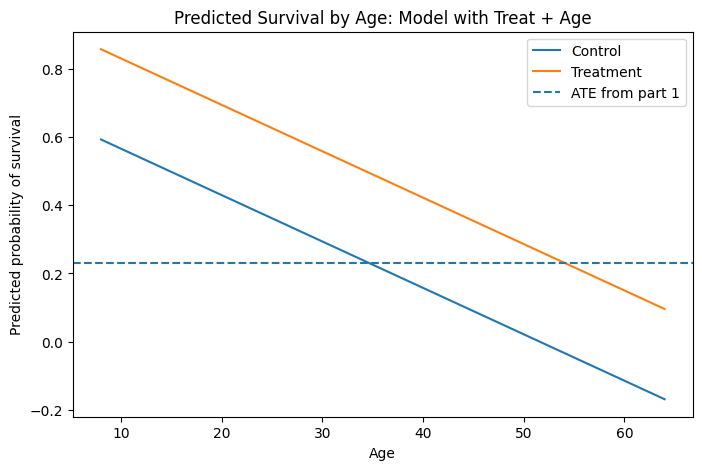


Part 3 treatment coefficient: 0.2647016865036755


In [36]:
# =========================
# 3. Regress y on transplant and age
# =========================
X2 = sm.add_constant(df[["treat", "age"]]).astype(float)
model2 = sm.OLS(y, X2).fit()

print("\n================ PART 3: y ~ treat + age ================\n")
print(model2.summary())

# predicted survival by age for control and treatment
age_grid = np.linspace(df["age"].min(), df["age"].max(), 200)

pred_part3 = pd.DataFrame({
    "age": np.concatenate([age_grid, age_grid]),
    "treat": np.concatenate([np.zeros(len(age_grid)), np.ones(len(age_grid))])
})

X_pred2 = sm.add_constant(pred_part3[["treat", "age"]], has_constant="add").astype(float)
pred_part3["pred_y"] = model2.predict(X_pred2)

control_pred3 = pred_part3[pred_part3["treat"] == 0]
treat_pred3 = pred_part3[pred_part3["treat"] == 1]

plt.figure(figsize=(8, 5))
plt.plot(control_pred3["age"], control_pred3["pred_y"], label="Control")
plt.plot(treat_pred3["age"], treat_pred3["pred_y"], label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted Survival by Age: Model with Treat + Age")
plt.legend()
plt.show()

# treatment effect in part 3 is constant across age
part3_effect = model2.params["treat"]
print("\nPart 3 treatment coefficient:", part3_effect)



================ PART 4: y ~ treat + age + treat*age ================

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000310
Time:                        07:24:49   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

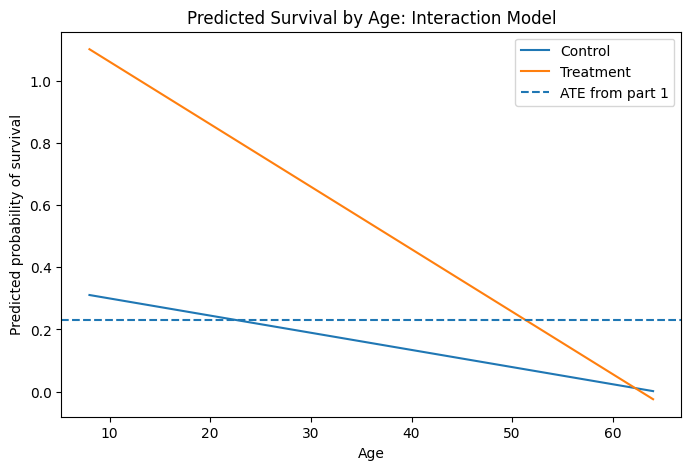

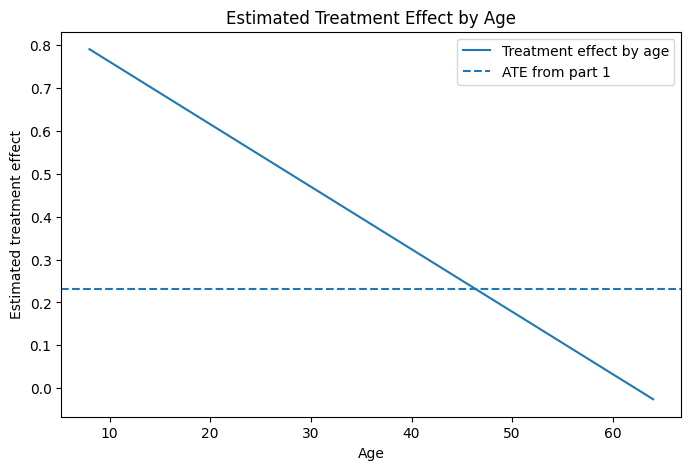


Interaction model treatment effect formula:
Effect(age) = 0.9077513885685915 + -0.014590638256855354 * age

Ages where interaction-model effect > ATE: (np.float64(8.0), np.float64(46.2713567839196))
Ages where interaction-model effect < ATE: (np.float64(46.552763819095475), np.float64(64.0))


In [37]:
# =========================
# 4. Regress y on transplant, age, and interaction
# =========================
df["treat_age"] = df["treat"] * df["age"]

X3 = sm.add_constant(df[["treat", "age", "treat_age"]]).astype(float)
model3 = sm.OLS(y, X3).fit()

print("\n================ PART 4: y ~ treat + age + treat*age ================\n")
print(model3.summary())

pred_part4 = pd.DataFrame({
    "age": np.concatenate([age_grid, age_grid]),
    "treat": np.concatenate([np.zeros(len(age_grid)), np.ones(len(age_grid))])
})
pred_part4["treat_age"] = pred_part4["treat"] * pred_part4["age"]

X_pred3 = sm.add_constant(pred_part4[["treat", "age", "treat_age"]], has_constant="add").astype(float)
pred_part4["pred_y"] = model3.predict(X_pred3)

control_pred4 = pred_part4[pred_part4["treat"] == 0]
treat_pred4 = pred_part4[pred_part4["treat"] == 1]

plt.figure(figsize=(8, 5))
plt.plot(control_pred4["age"], control_pred4["pred_y"], label="Control")
plt.plot(treat_pred4["age"], treat_pred4["pred_y"], label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted Survival by Age: Interaction Model")
plt.legend()
plt.show()

# age-specific treatment effect in interaction model
age_effect = model3.params["treat"] + model3.params["treat_age"] * age_grid

plt.figure(figsize=(8, 5))
plt.plot(age_grid, age_effect, label="Treatment effect by age")
plt.axhline(ate, linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Estimated treatment effect")
plt.title("Estimated Treatment Effect by Age")
plt.legend()
plt.show()

# where interaction effect is above or below ATE
over_ages = age_grid[age_effect > ate]
under_ages = age_grid[age_effect < ate]

print("\nInteraction model treatment effect formula:")
print("Effect(age) =",
      model3.params["treat"], "+", model3.params["treat_age"], "* age")

if len(over_ages) > 0:
    print("\nAges where interaction-model effect > ATE:", (over_ages.min(), over_ages.max()))
else:
    print("\nNo ages where interaction-model effect > ATE")

if len(under_ages) > 0:
    print("Ages where interaction-model effect < ATE:", (under_ages.min(), under_ages.max()))
else:
    print("No ages where interaction-model effect < ATE")

In [38]:
# =========================
# 5. 10-fold cross validation
# =========================
kf = KFold(n_splits=10, shuffle=True, random_state=1)
lr = LinearRegression()

# model 1: y ~ treat
X_cv1 = df[["treat"]].astype(float)

# model 2: y ~ treat + age
X_cv2 = df[["treat", "age"]].astype(float)

# model 3: y ~ treat + age + interaction
X_cv3 = df[["treat", "age", "treat_age"]].astype(float)

mse1 = -cross_val_score(lr, X_cv1, y, cv=kf, scoring="neg_mean_squared_error").mean()
mse2 = -cross_val_score(lr, X_cv2, y, cv=kf, scoring="neg_mean_squared_error").mean()
mse3 = -cross_val_score(lr, X_cv3, y, cv=kf, scoring="neg_mean_squared_error").mean()

r2_1 = cross_val_score(lr, X_cv1, y, cv=kf, scoring="r2").mean()
r2_2 = cross_val_score(lr, X_cv2, y, cv=kf, scoring="r2").mean()
r2_3 = cross_val_score(lr, X_cv3, y, cv=kf, scoring="r2").mean()

print("\n================ PART 5: CROSS VALIDATION ================\n")
print("Model 1: y ~ treat")
print("CV Mean MSE:", mse1)
print("CV Mean R^2:", r2_1)

print("\nModel 2: y ~ treat + age")
print("CV Mean MSE:", mse2)
print("CV Mean R^2:", r2_2)

print("\nModel 3: y ~ treat + age + treat*age")
print("CV Mean MSE:", mse3)
print("CV Mean R^2:", r2_3)


================ PART 5: CROSS VALIDATION ================

Model 1: y ~ treat
CV Mean MSE: 0.19497249586192156
CV Mean R^2: -0.0011081935172854607

Model 2: y ~ treat + age
CV Mean MSE: 0.17926415954952163
CV Mean R^2: 0.07011425737924556

Model 3: y ~ treat + age + treat*age
CV Mean MSE: 0.17880206762517337
CV Mean R^2: 0.06915008283101601


In [39]:
# =========================
# 6. Model concerns
# =========================
print("\n================ PART 6: MODEL CONCERNS ================\n")
print("1. Treatment is not randomly assigned, so selection bias may be present.")
print("2. Age alone may not be enough to control for health differences across patients.")
print("3. A linear probability model can predict probabilities below 0 or above 1.")
print("4. Using this model for prioritization could create unfair access decisions.")
print("5. Ethical deployment would require stronger causal design and fairness review.")


================ PART 6: MODEL CONCERNS ================

1. Treatment is not randomly assigned, so selection bias may be present.
2. Age alone may not be enough to control for health differences across patients.
3. A linear probability model can predict probabilities below 0 or above 1.
4. Using this model for prioritization could create unfair access decisions.
5. Ethical deployment would require stronger causal design and fairness review.
